# EDA

Каталог трёх категорий (очки, чехлы для телефонов, вешалки) из выдачи WB и отзывы по этим товарам из датасета wb-feedbacks, связь по nmId. Табличная задача — предсказать средний рейтинг карточки (RMSE / MAE), текстовая — оценку отзыва 1–5 по тексту (macro-F1)

In [1]:
import json
import os
import sys
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
os.environ["HF_HUB_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

sys.path.append("..")
from src.utils import load_config

cfg = load_config()
seed = cfg["random_seed"]
np.random.seed(seed)
PROC = Path("../data/processed")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_colwidth", 90)

## Каталог товаров

In [2]:
tab = pd.read_parquet(PROC / "tabular_clean.parquet")
tab_train = pd.read_parquet(PROC / "tabular_train.parquet")
tab_val = pd.read_parquet(PROC / "tabular_val.parquet")
tab_test = pd.read_parquet(PROC / "tabular_test.parquet")
print("каталог:", len(tab), "| train:", len(tab_train), "| val:", len(tab_val), "| test:", len(tab_test))
tab.head()

каталог: 10443 | train: 7309 | val: 1045 | test: 2089


,nmId,name,brand,category,price,rating,n_reviews,n_photos,n_colors,title_len
0,390513300,Очки имиджевые прозрачные y2k,Sicilist,glasses,149.0,4.6,16982,11,1,29
1,783882748,Очки солнцезащитные черные тренд 2026,Sicilist,glasses,178.0,4.7,2494,12,1,37
2,390514728,Очки имиджевые прозрачные y2k,Sicilist,glasses,149.0,4.7,8381,7,1,29
3,813181933,Очки увеличительные,Очки-лупа,glasses,122.0,4.6,669,8,0,19
4,841640444,Солнцезащитные очки квадратные,unknown,glasses,105.0,4.9,414,4,1,30


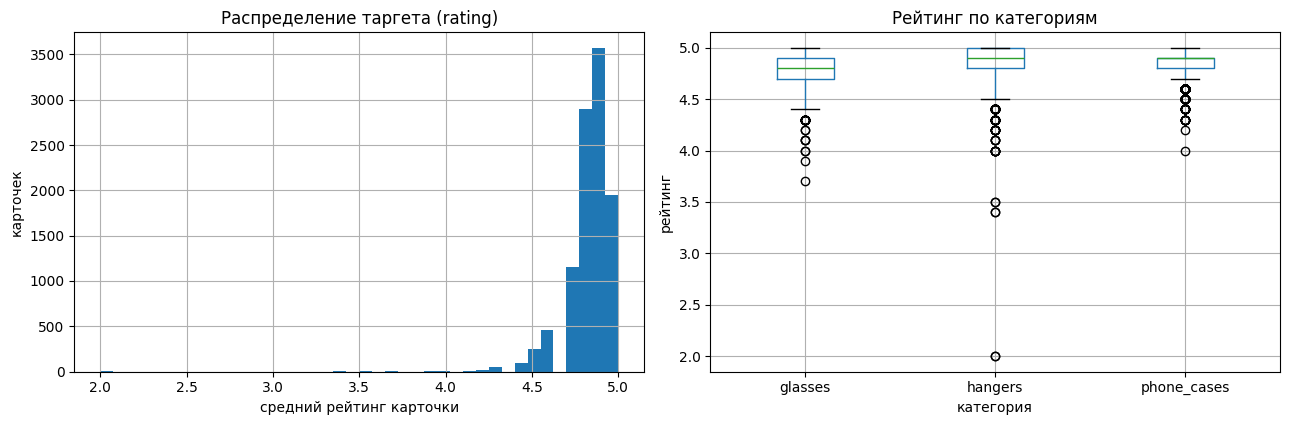

карточек с рейтингом ниже 4.5: 1.7 %


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(tab["rating"], bins=40)
axes[0].set_xlabel("средний рейтинг карточки")
axes[0].set_ylabel("карточек")
axes[0].set_title("Распределение таргета (rating)")
tab.boxplot(column="rating", by="category", ax=axes[1])
axes[1].set_xlabel("категория")
axes[1].set_ylabel("рейтинг")
axes[1].set_title("Рейтинг по категориям")
fig.suptitle("")
plt.tight_layout()
plt.show()
print("карточек с рейтингом ниже 4.5:", round((tab["rating"] < 4.5).mean() * 100, 1), "%")

Почти весь каталог — карточки с рейтингом 4.5–5.0, низких совсем мало. Предсказывать среднее тут легко, интерес в том, чтобы находить редкие проблемные карточки

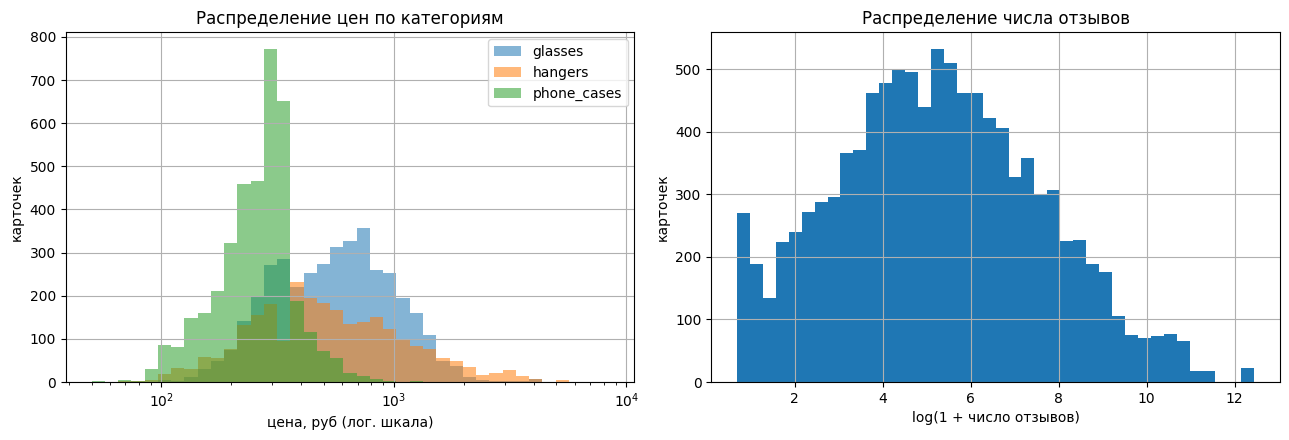

медианная цена по категориям: {'glasses': 561.0, 'hangers': 480.0, 'phone_cases': 274.0}


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.geomspace(tab["price"].min(), tab["price"].max(), 40)
for c in sorted(tab["category"].unique()):
    axes[0].hist(tab.loc[tab["category"] == c, "price"], bins=bins, alpha=0.55, label=c)
axes[0].set_xscale("log")
axes[0].set_xlabel("цена, руб (лог. шкала)")
axes[0].set_ylabel("карточек")
axes[0].set_title("Распределение цен по категориям")
axes[0].legend()
axes[1].hist(np.log1p(tab["n_reviews"]), bins=40)
axes[1].set_xlabel("log(1 + число отзывов)")
axes[1].set_ylabel("карточек")
axes[1].set_title("Распределение числа отзывов")
plt.tight_layout()
plt.show()
print("медианная цена по категориям:", tab.groupby("category")["price"].median().to_dict())

Цена и число отзывов скошены вправо, как обычно на маркетплейсах, поэтому в пайплайне перед StandardScaler к ним применяется log1p

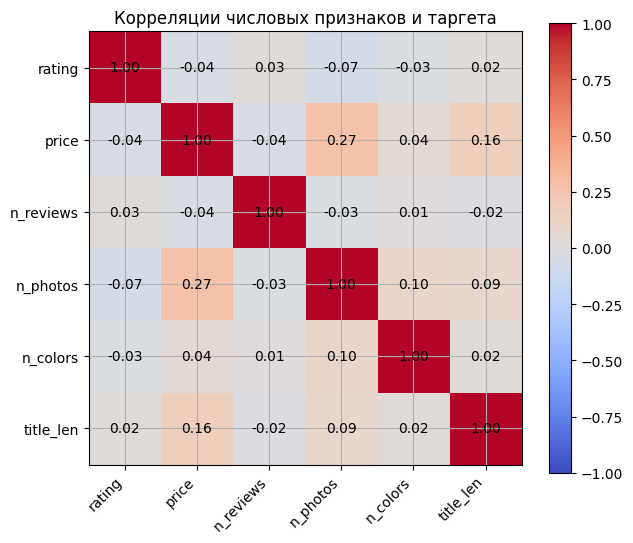

In [5]:
num_cols = ["rating", "price", "n_reviews", "n_photos", "n_colors", "title_len"]
corr = tab[num_cols].astype(float).corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im)
ax.set_title("Корреляции числовых признаков и таргета")
plt.tight_layout()
plt.show()

Сильных линейных связей с рейтингом нет, всё в пределах 0.1. Утечки тоже нет: в признаках нет самого рейтинга или его производных, n_reviews — это количество отзывов, а не оценка

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from src.preprocess import build_tabular_preprocessor

target = cfg["tabular"]["target"]
features = cfg["tabular"]["features"]
pre = build_tabular_preprocessor(cfg)
X_train = pre.fit_transform(tab_train[features], tab_train[target])
X_val = pre.transform(tab_val[features])

base_pred = np.full(len(tab_val), tab_train[target].mean())
print("бейзлайн-константа (среднее train), val: RMSE",
      round(root_mean_squared_error(tab_val[target], base_pred), 4),
      "| MAE", round(mean_absolute_error(tab_val[target], base_pred), 4))

rf = RandomForestRegressor(n_estimators=300, random_state=seed, n_jobs=-1)
rf.fit(X_train, tab_train[target])
rf_pred = rf.predict(X_val)
print("RandomForest, val: RMSE",
      round(root_mean_squared_error(tab_val[target], rf_pred), 4),
      "| MAE", round(mean_absolute_error(tab_val[target], rf_pred), 4))

бейзлайн-константа (среднее train), val: RMSE 0.1399 | MAE 0.1065


RandomForest, val: RMSE 0.1283 | MAE 0.0854


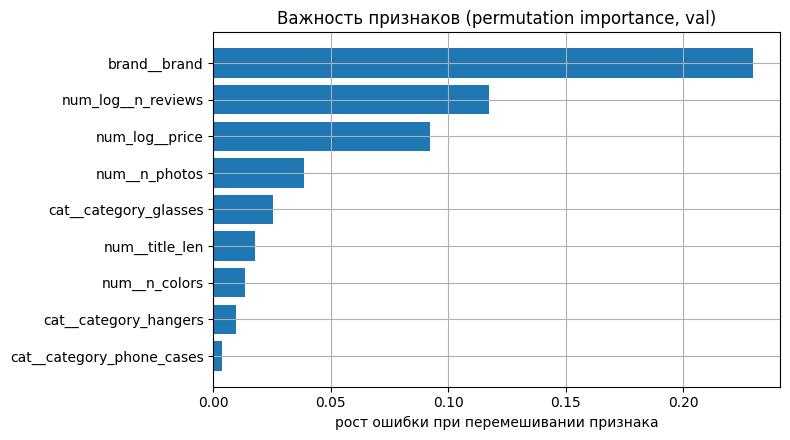

In [7]:
imp = permutation_importance(rf, X_val, tab_val[target], n_repeats=10, random_state=seed)
names = pre.get_feature_names_out()
order = imp.importances_mean.argsort()
plt.figure(figsize=(8, 4.5))
plt.barh(np.array(names)[order], imp.importances_mean[order])
plt.xlabel("рост ошибки при перемешивании признака")
plt.title("Важность признаков (permutation importance, val)")
plt.tight_layout()
plt.show()

## Отзывы

In [8]:
txt = pd.read_parquet(PROC / "text_clean.parquet")
txt_train = pd.read_parquet(PROC / "text_train.parquet")
txt_val = pd.read_parquet(PROC / "text_val.parquet")
txt_test = pd.read_parquet(PROC / "text_test.parquet")
print("отзывов:", len(txt), "| train:", len(txt_train), "| val:", len(txt_val), "| test:", len(txt_test))
txt[["nmId", "category", "mark", "text", "text_norm"]].head()

отзывов: 33186 | train: 23229 | val: 3319 | test: 6638


,nmId,category,mark,text,text_norm
0,152349762,hangers,5,"Соответствует описанию! Аккуратная, небольшая вешалка! Нам подошла! Спасибо!","соответствует описанию! аккуратная, небольшая вешалка! нам подошла! спасибо!"
1,41644939,glasses,5,"Очки просто высший класс, спасибо. Плюс футлярчик салфетка, шнурок я в восторге. Спасибо","очки просто высший класс, спасибо. плюс футлярчик салфетка, шнурок я в восторге. спасибо"
2,21060213,phone_cases,1,"Чехол пришёл на указанную модель,размер не подходит. Чехол маленький.","чехол пришел на указанную модель,размер не подходит. чехол маленький."
3,147322543,glasses,5,"Спасибо продавцу за быструю отправку. Товар пришёл вовремя, продавца рекомендую. Очки ...","спасибо продавцу за быструю отправку. товар пришел вовремя, продавца рекомендую. очки ..."
4,74978573,glasses,4,"А чего,на меня футляра не хватило?В канун Нового года?🤣Странно,что так стрёмно упакова...","а чего,на меня футляра не хватило?в канун нового года? странно,что так стремно упакова..."


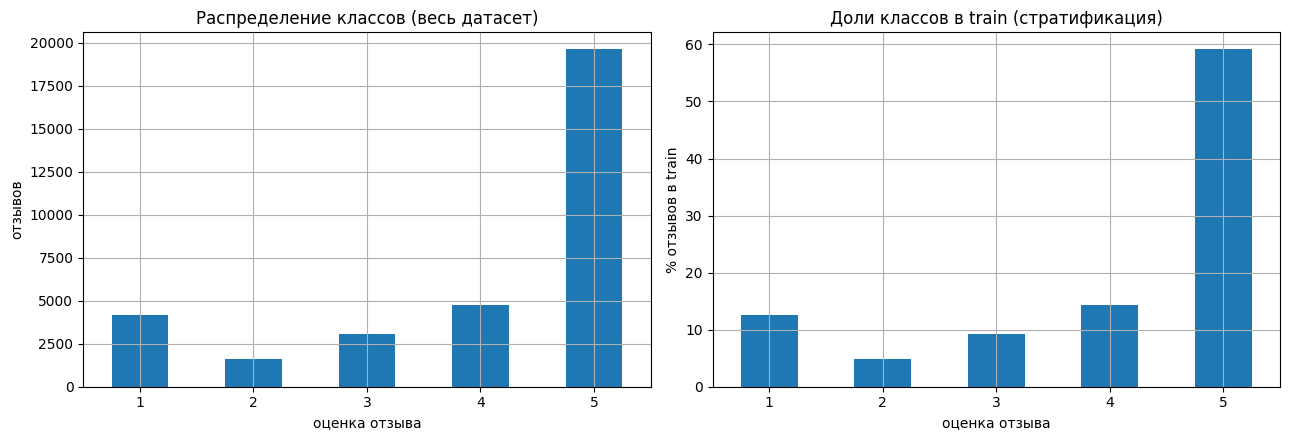

веса классов (по train): {'1': 1.597, '2': 4.0968, '3': 2.177, '4': 1.4036, '5': 0.3381}


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
txt["mark"].value_counts().sort_index().plot(kind="bar", rot=0, ax=axes[0])
axes[0].set_xlabel("оценка отзыва")
axes[0].set_ylabel("отзывов")
axes[0].set_title("Распределение классов (весь датасет)")
share = txt_train["mark"].value_counts(normalize=True).sort_index() * 100
share.plot(kind="bar", rot=0, ax=axes[1])
axes[1].set_xlabel("оценка отзыва")
axes[1].set_ylabel("% отзывов в train")
axes[1].set_title("Доли классов в train (стратификация)")
plt.tight_layout()
plt.show()
weights = json.loads((PROC / "class_weights.json").read_text())
print("веса классов (по train):", weights["weights"])

Дисбаланс сильный: пятёрок 60% даже после обрезки до 20 тысяч (в исходном потоке их 83%), двоек меньше 5%. План на этап 5 — веса классов в лоссе, они посчитаны по train и лежат в `class_weights.json`. Оверсэмплинг оставили про запас: на коротких однотипных отзывах он быстро ведёт к переобучению. Сплиты стратифицированы по оценке, поэтому доли классов в train/val/test совпадают

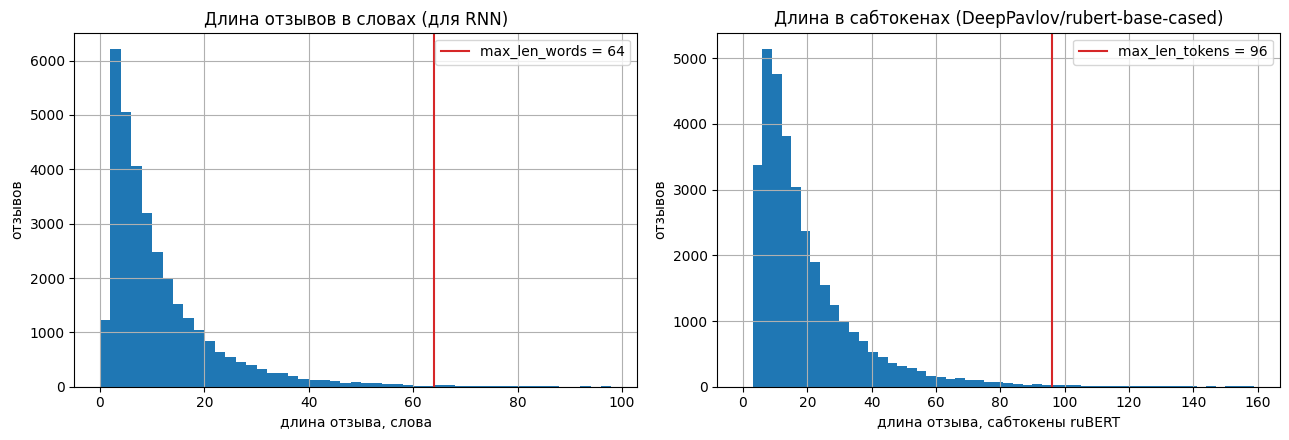

слова: медиана 8 | p95 33 | p99 56
сабтокены: медиана 14 | p95 52 | p99 86


In [10]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained(cfg["text"]["bert_model"])
sub_lens = pd.Series([len(x) for x in tok(txt["text"].tolist())["input_ids"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(txt["n_words"], bins=range(0, 100, 2))
axes[0].axvline(cfg["text"]["max_len_words"], color="C3", label="max_len_words = " + str(cfg["text"]["max_len_words"]))
axes[0].set_xlabel("длина отзыва, слова")
axes[0].set_ylabel("отзывов")
axes[0].set_title("Длина отзывов в словах (для RNN)")
axes[0].legend()
axes[1].hist(sub_lens, bins=range(0, 160, 3))
axes[1].axvline(cfg["text"]["max_len_tokens"], color="C3", label="max_len_tokens = " + str(cfg["text"]["max_len_tokens"]))
axes[1].set_xlabel("длина отзыва, сабтокены ruBERT")
axes[1].set_ylabel("отзывов")
axes[1].set_title("Длина в сабтокенах (" + cfg["text"]["bert_model"] + ")")
axes[1].legend()
plt.tight_layout()
plt.show()
print("слова: медиана", int(txt["n_words"].median()), "| p95", int(txt["n_words"].quantile(0.95)), "| p99", int(txt["n_words"].quantile(0.99)))
print("сабтокены: медиана", int(sub_lens.median()), "| p95", int(sub_lens.quantile(0.95)), "| p99", int(sub_lens.quantile(0.99)))

Длину режем по 99 перцентилю: 64 слова для RNN и 96 сабтокенов для ruBERT, значения записаны в config.yaml. Так паддинг не раздувает батчи, а обрезка теряет меньше процента отзывов. ruBERT — cased-модель, ей отдаём исходный text, RNN работает по нормализованному text_norm

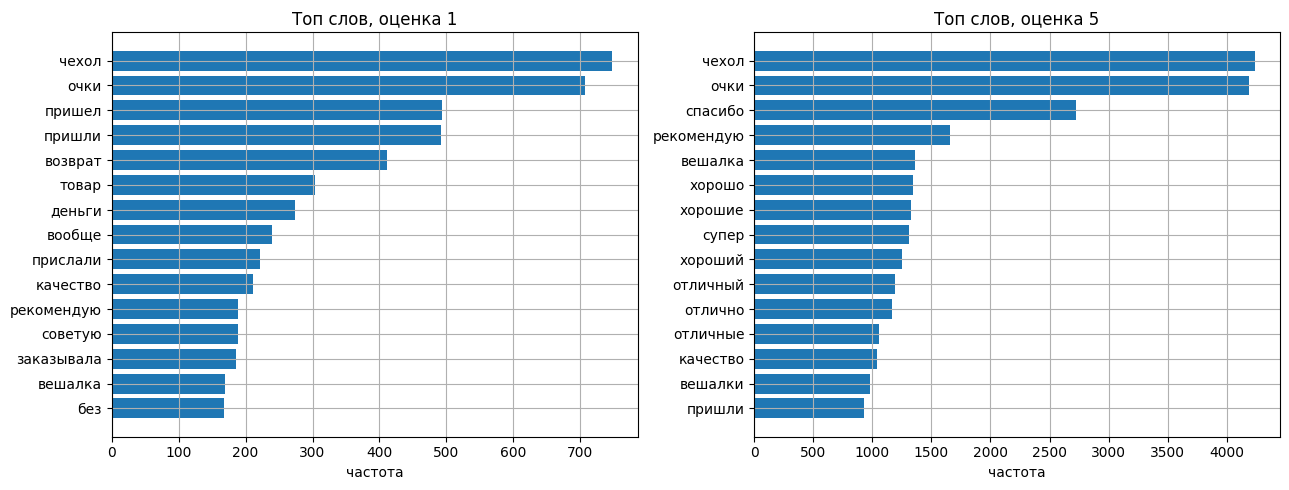

медиана слов: оценка 1-2 - 11 | оценка 5 - 6


In [11]:
STOP = set(
    "и в не на с но за по как что это очень а к у же из для от так все мне бы было "
    "только или его еще нет да при о вы мы они он она ну там вот ли был была были сам "
    "мой моя мои до том чем теперь когда даже их если ее меня тоже после этом ним ней "
    "может просто более раз уже под себе свой свою то во со таки них кто куда где".split()
)

def top_words(series, n=15):
    cnt = Counter()
    for t in series:
        for w in t.split():
            w = w.strip(".,!?:;()%+-/")
            if len(w) > 2 and w not in STOP and not w.isdigit():
                cnt[w] += 1
    return cnt.most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mark in zip(axes, [1, 5]):
    words = top_words(txt.loc[txt["mark"] == mark, "text_norm"])
    ax.barh([w for w, _ in words][::-1], [c for _, c in words][::-1])
    ax.set_xlabel("частота")
    ax.set_title("Топ слов, оценка " + str(mark))
plt.tight_layout()
plt.show()
print("медиана слов: оценка 1-2 -", int(txt.loc[txt["mark"] <= 2, "n_words"].median()),
      "| оценка 5 -", int(txt.loc[txt["mark"] == 5, "n_words"].median()))

С топом слов есть подвох: не — стоп-слово, поэтому рекомендую и советую в топе единиц на самом деле не рекомендую и не советую. Кроме них в единицах — возврат, деньги, прислали, в пятёрках — спасибо, отлично, супер. Слова про поломки (брак, сломалась) в топ не пробились, потому что размазаны по словоформам — их собирают правила аспектов. Негатив почти вдвое длиннее позитива: медиана 11 слов против 6. И раз мешок слов теряет отрицания, для этапа 5 это довод в пользу моделей, которые видят порядок слов

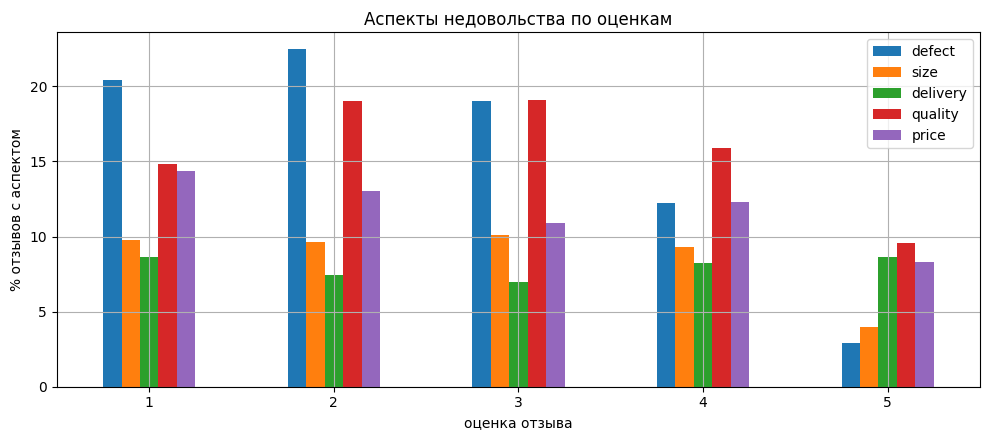

негатив (1-2): хотя бы один аспект у 51.9 % отзывов


In [12]:
aspect_cols = [c for c in txt.columns if c.startswith("aspect_")]
aspect_names = [c.replace("aspect_", "") for c in aspect_cols]
share = txt.groupby("mark")[aspect_cols].mean() * 100
share.columns = aspect_names
ax = share.plot(kind="bar", rot=0, figsize=(10, 4.5))
ax.set_xlabel("оценка отзыва")
ax.set_ylabel("% отзывов с аспектом")
ax.set_title("Аспекты недовольства по оценкам")
plt.tight_layout()
plt.show()
neg = txt[txt["mark"] <= 2]
print("негатив (1-2): хотя бы один аспект у", round(neg[aspect_cols].any(axis=1).mean() * 100, 1), "% отзывов")

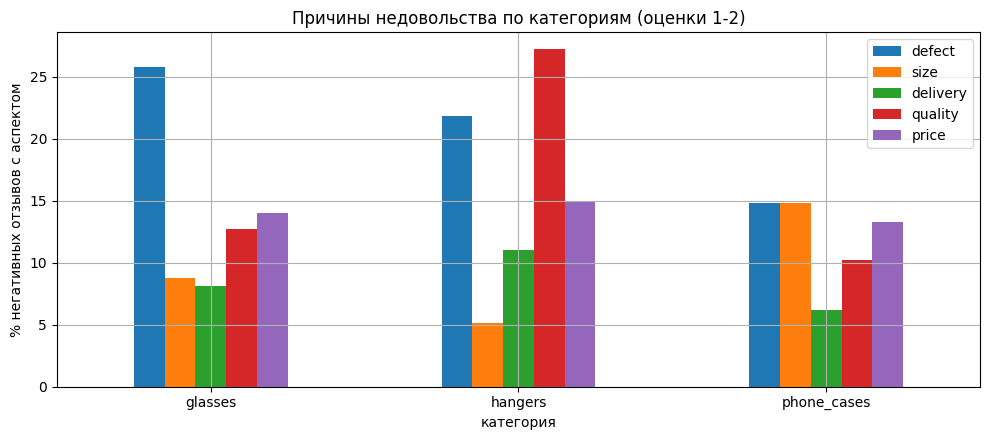

,category,mark,text,aspect
22,glasses,2,"Объективно- какая цена-такие и очки. Цвет не белый, а больше в желтизну. Пластик легки...",defect
48,glasses,1,Очки конечно хорошие но царапина прямо на месте зрачка как-то не очень полезно для зре...,defect
2,phone_cases,1,"Чехол пришёл на указанную модель,размер не подходит. Чехол маленький.",size
99,glasses,1,"Не стоят даже половины своей стоимости. Очки не удобные, не держатся на переносице воо...",size
199,hangers,1,Стала открывать упаковку и плечики стали разваливаться отлетели сразу же по бокам сини...,delivery
452,glasses,2,"В целом вид прикольный. В ПВЗ распечатал и увидел, что дужка смещена, подумал, что отк...",delivery
76,hangers,1,"Разваливается вся, шатается из стороны в сторону. Не советую",quality
93,hangers,1,"Хлипкие, и вовсе неудобно",quality
15,glasses,1,Пришли с трещенной. Удержали за возврат 75 рублей. Огорчили,price
22,glasses,2,"Объективно- какая цена-такие и очки. Цвет не белый, а больше в желтизну. Пластик легки...",price


In [13]:
cat_share = neg.groupby("category")[aspect_cols].mean() * 100
cat_share.columns = aspect_names
ax = cat_share.plot(kind="bar", rot=0, figsize=(10, 4.5))
ax.set_xlabel("категория")
ax.set_ylabel("% негативных отзывов с аспектом")
ax.set_title("Причины недовольства по категориям (оценки 1-2)")
plt.tight_layout()
plt.show()
examples = pd.concat(
    [neg[neg[c]].head(2)[["category", "mark", "text"]].assign(aspect=name)
     for c, name in zip(aspect_cols, aspect_names)]
)
examples

Аспекты размечаем правилами: слова отзыва приводим к леммам через pymorphy3, чтобы одна запись в словаре ловила все падежи и формы (сломалась, сломанные, сломаться), и сравниваем со словарями из `src/aspects.py`, плюс несколько устойчивых фраз вроде
не подошел и деньги на ветер. Обучения здесь нет, готовых меток аспектов в данных тоже — это аналитический слой поверх классификатора оценки

In [14]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words=list(STOP), min_df=5)
X_neg = vec.fit_transform(neg["text_norm"])
nmf = NMF(n_components=5, random_state=seed)
nmf.fit(X_neg)
terms = vec.get_feature_names_out()
for i, comp in enumerate(nmf.components_):
    top = terms[comp.argsort()[-8:]][::-1]
    print("тема", i + 1, ":", ", ".join(top))

тема 1 : пришли, кривые, очки пришли, пришли кривые, те, пришли те, отказ, поцарапанные
тема 2 : чехол, телефон, подошел, чехол пришел, вообще, подходит, кнопки, пришел чехол
тема 3 : очки, очки пришли, те очки, те, прислали, маленькие, другие, другие очки
тема 4 : пришел, тот, пришел тот, товар, тот чехол, цвет, прислали, тот товар
тема 5 : качество, вешалка, возврат, хлипкая, рекомендую, деньги, советую, ужасное


Темы NMF на негативе повторяют те же сюжеты — брак, не подошло, качество. Значит словари аспектов ничего крупного не упускают

## Выводы

1. Каталог почти целиком хороший: 98.3% карточек с рейтингом 4.5 и выше, средний 4.84. Связь рейтинга с атрибутами слабая, так что польза табличной модели — находить редкий хвост проблемных карточек, а не объяснять среднее
2. Чем больше отзывов, тем ниже рейтинг: идеальные 5.0 обычно у карточек с парой отзывов. Число отзывов работает ещё и как мера достоверности рейтинга
3. Оценки сильно перекошены: в исходном потоке 83% пятёрок, двоек меньше 5%. Поэтому в текстовой задаче считаем macro-F1 и берём веса классов в лоссе
4. Негатив информативнее позитива: медиана 11 слов против 6, и у половины негативных отзывов определяется конкретный аспект недовольства
5. Главная причина низких оценок — брак: аспект дефект у 21% отзывов с оценкой 1–2 против 3% у пятёрок, размер — 10% против 4%. Доставка упоминается в негативе и позитиве одинаково, цена чаще в негативе, но и в позитиве её хватает — сами по себе оценку они не объясняют
6. Причины разные по категориям: у вешалок 27% негатива про качество и материалы, у чехлов 15% про размер и совместимость с моделью телефона, у очков 26% про брак. Продавцам нужны разные действия: вешалки — контроль материалов, чехлы — таблица совместимости, очки — контроль брака и упаковка